## Step 1 - Environment setup
The core scientific Python stack is loaded here, the random seed is fixed, and print/display options are standardized so every later analysis cell remains reproducible.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(suppress=True, linewidth=140)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 120)

RANDOM_SEED = 1337  # fixed seed for deterministic splits
N_SPLITS = 5        # using a 5-fold cross validation
USE_PCA = False

## Step 2 - Resolve data paths
This block verifies the repository layout, locates the RNA/TE/CIGS files inside `data/`, and fails fast if anything is missing so downstream cells do not crash mid-run.

In [2]:
from pathlib import Path
from typing import Iterable

REPO_ROOT = Path.cwd()
DATA_DIR = REPO_ROOT / "data"

def resolve_existing_file(candidates: Iterable[str]) -> Path:
    for name in candidates:
        candidate_path = DATA_DIR / name
        if candidate_path.exists():
            return candidate_path
    return DATA_DIR / next(iter(candidates))

PATH_RNA_COUNTS = resolve_existing_file(["RNA_HEK293T.csv"])
PATH_TE_COUNTS = resolve_existing_file(["TE_HEK293T.csv"])
PATH_COUNTS = resolve_existing_file([
    "MCE_Bioactive_Compounds_HEK293T_10uM_Counts.xlsx",
    "MCE_Bioactive_Compounds_HEK293T_10μM_Counts.xlsx",
    "MCE_Bioactive_Compounds_HEK293T_10µM_Counts.xlsx",
])
PATH_METADATA = resolve_existing_file([
    "MCE_Bioactive_Compounds_HEK293T_10uM_MetaData.xlsx",
    "MCE_Bioactive_Compounds_HEK293T_10μM_MetaData.xlsx",
    "MCE_Bioactive_Compounds_HEK293T_10µM_MetaData.xlsx",
])

print("Data dir:", DATA_DIR)
print("Using RNA counts:", PATH_RNA_COUNTS.name)
print("Using TE counts:", PATH_TE_COUNTS.name)
print("Using CIGS counts:", PATH_COUNTS.name)
print("Using CIGS metadata:", PATH_METADATA.name)

required_files = {
    "RNA counts": PATH_RNA_COUNTS,
    "TE counts": PATH_TE_COUNTS,
    "CIGS counts": PATH_COUNTS,
    "CIGS metadata": PATH_METADATA,
}
missing_required = [name for name, path in required_files.items() if not path.exists()]
if missing_required:
    raise FileNotFoundError(f"Missing required data files: {', '.join(missing_required)}")
print("All required data files found.")

Data dir: c:\Users\lintu\cs370\data
Using RNA counts: RNA_HEK293T.csv
Using TE counts: TE_HEK293T.csv
Using CIGS counts: MCE_Bioactive_Compounds_HEK293T_10μM_Counts.xlsx
Using CIGS metadata: MCE_Bioactive_Compounds_HEK293T_10μM_MetaData.xlsx
All required data files found.


## Step 3 - Reusable helpers
This step defines lightweight cleaners (drop stray index columns, infer ID fields, compute Pearson safely, add gene symbols) to keep the analytical sections compact.

In [3]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def drop_index_like(df: pd.DataFrame) -> pd.DataFrame:
    return df.drop(columns=["Unnamed: 0"], errors="ignore")

def pick_id_col(cols) -> str:
    for c in ["gene", "transcript", "feature_id", "id"]:
        if c in cols: return c
    return cols[0]

def safe_pearsonr(a: np.ndarray, b: np.ndarray) -> float:
    if np.std(a) == 0 or np.std(b) == 0:
        return float("nan")
    r = np.corrcoef(a, b)[0,1]
    return float(r) if np.isfinite(r) else float("nan")

def eval_per_gene(y_true: np.ndarray, y_pred: np.ndarray, ids) -> pd.DataFrame:
    rows = []
    for j, gid in enumerate(ids):
        yt = y_true[:, j]; yp = y_pred[:, j]
        r  = safe_pearsonr(yt, yp)
        ss_res = np.sum((yt - yp)**2)
        ss_tot = np.sum((yt - np.mean(yt))**2)
        r2 = float("nan") if ss_tot == 0 else 1.0 - (ss_res/ss_tot)
        mae = mean_absolute_error(yt, yp)
        rmse = mean_squared_error(yt, yp)
        rows.append({"id": gid, "pearson_r": r, "r2": r2, "mae": mae, "rmse": rmse})
    return pd.DataFrame(rows)

def to_gene_symbols(df: pd.DataFrame, id_col: str, tx2gene: pd.DataFrame=None) -> pd.DataFrame:
    if tx2gene is None or not set(["transcript","gene_symbol"]).issubset(tx2gene.columns):
        out = df.copy(); out["gene_symbol"] = out[id_col].astype(str); return out
    if id_col.lower() != "transcript":
        out = df.copy(); out["gene_symbol"] = out[id_col].astype(str); return out
    out = df.merge(tx2gene[["transcript","gene_symbol"]], left_on=id_col, right_on="transcript", how="left")
    out["gene_symbol"] = out["gene_symbol"].fillna(out[id_col].astype(str))
    out = out.drop(columns=["transcript_y"], errors="ignore")
    out = out.rename(columns={"transcript_x":"transcript"})
    return out

def rps_rpl_mask(symbols: pd.Series) -> pd.Series:
    s = symbols.fillna("").str.upper()
    return s.str.startswith("RPS") | s.str.startswith("RPL")

## Step 4 - Align RNA and TE matrices
This stage brings the RNA and TE tables onto the same sample/gene axes, renames IDs consistently, and logs the resulting shapes so every model sees matched inputs.

In [4]:
rna = drop_index_like(pd.read_csv(PATH_RNA_COUNTS))
te  = drop_index_like(pd.read_csv(PATH_TE_COUNTS))

id_col_rna = pick_id_col(rna.columns.tolist())
id_col_te  = pick_id_col(te.columns.tolist())

sample_cols = [c for c in rna.columns if c != id_col_rna and c in te.columns]
rna = rna[[id_col_rna] + sample_cols].copy()
te  = te [[id_col_te ] + sample_cols].copy()

common_ids = sorted(set(rna[id_col_rna]) & set(te[id_col_te]))
rna = rna[rna[id_col_rna].isin(common_ids)].sort_values(id_col_rna).reset_index(drop=True)
te  = te [te [id_col_te ].isin(common_ids)].sort_values(id_col_te ).reset_index(drop=True)

rna = rna.rename(columns={id_col_rna: "feature_id"})
te  = te .rename(columns={id_col_te:  "feature_id"})

print("RNA shape:", rna.shape)
print("TE  shape:", te.shape)
print("Samples:", len(sample_cols))

RNA shape: (8433, 99)
TE  shape: (8433, 99)
Samples: 98


## Step 5 - Build modeling matrices
This converts the aligned tables into NumPy matrices (`X` for RNA predictors, `Y` for TE targets) and stores gene metadata that we repeatedly reference in later analyses.

In [5]:
tx2gene = None
rna_sym = to_gene_symbols(rna, "feature_id", tx2gene)
te_sym  = to_gene_symbols(te,  "feature_id", tx2gene)

genes = rna["feature_id"].tolist()
gene_symbols = rna_sym["gene_symbol"].tolist()

X = rna[sample_cols].T.values  # RNA
Y = te [sample_cols].T.values  # TE

print("Matrix shapes — X:", X.shape, "Y:", Y.shape)

Matrix shapes — X: (98, 8433) Y: (98, 8433)


## Step 6 - Cluster-level Lasso sanity checks
The next three cells run cross-validated Lasso models on the RPS/RPL clusters, refit them on the full cohort, and visualize the highest-weight RNA drivers as an early biological sanity check.

In [6]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LassoCV
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error

def cv_predict_vector(X, y, alphas=None, n_splits=5, random_state=1337):
    if alphas is None:
        alphas = np.logspace(-3, 1, 20)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    yhat = np.empty_like(y, dtype=float)
    chosen, nnz = [], []
    for tr, te in kf.split(X):
        lcv = LassoCV(alphas=alphas, cv=5, random_state=random_state, n_jobs=-1, max_iter=10000)
        lcv.fit(X[tr], y[tr])
        yhat[te] = lcv.predict(X[te])
        chosen.append(lcv.alpha_)
        nnz.append(np.count_nonzero(lcv.coef_))
    return yhat, np.array(chosen), np.array(nnz)

# Masks (expects gene_symbols: array-like of gene names)
sym = pd.Series(gene_symbols).str.upper()
rps_mask = sym.str.startswith("RPS").values
rpl_mask = sym.str.startswith("RPL").values

# Cluster targets (mean TE across genes in cluster)
TE_RPS = np.nanmean(Y[:, rps_mask], axis=1)
TE_RPL = np.nanmean(Y[:, rpl_mask], axis=1)

# Run CV prediction
Yhat_RPS, alphas_rps, nnz_rps = cv_predict_vector(X, TE_RPS)
Yhat_RPL, alphas_rpl, nnz_rpl = cv_predict_vector(X, TE_RPL)

# Compact summary
def summarize(y, yhat, name):
    r = np.corrcoef(y, yhat)[0, 1] if (np.std(y) > 0 and np.std(yhat) > 0) else np.nan
    mae = mean_absolute_error(y, yhat)
    rmse = np.sqrt(mean_squared_error(y, yhat))
    print(f"{name}: r={r:.3f}, MAE={mae:.3f}, RMSE={rmse:.3f}")

summarize(TE_RPS, Yhat_RPS, "RPS cluster")
summarize(TE_RPL, Yhat_RPL, "RPL cluster")
print("Median alpha (RPS, RPL):", float(np.median(alphas_rps)), float(np.median(alphas_rpl)))
print("Median non-zero features (RPS, RPL):", int(np.median(nnz_rps)), int(np.median(nnz_rpl)))

RPS cluster: r=0.964, MAE=0.167, RMSE=0.240
RPL cluster: r=0.969, MAE=0.192, RMSE=0.268
Median alpha (RPS, RPL): 0.029763514416313176 0.018329807108324356
Median non-zero features (RPS, RPL): 14 29


In [7]:
from sklearn.linear_model import LassoCV

# Fit final Lasso model on full data (no scaling)
def fit_full_lasso(X_data, y, alpha):
    nan_mask = np.isnan(y)
    X_clean = X_data[~nan_mask]
    y_clean = y[~nan_mask]

    if len(y_clean) == 0:
        print("Warning: No non-NaN samples found for this target vector. Cannot fit model.")
        return None, None

    model = LassoCV(alphas=[alpha], cv=min(5, len(y_clean)), random_state=RANDOM_SEED, max_iter=10000).fit(X_clean, y_clean)
    return model, None

# Load and transpose RNA data explicitly for this cell
rna_for_lasso = drop_index_like(pd.read_csv(f"{DATA_DIR}/RNA_HEK293T.csv"))
id_col_rna_for_lasso = pick_id_col(rna_for_lasso.columns.tolist())
sample_cols_for_lasso = [c for c in rna_for_lasso.columns if c != id_col_rna_for_lasso]
X_lasso = rna_for_lasso[sample_cols_for_lasso].T.values

# Use median alpha values from cross-validation results
alpha_rps = float(np.nanmedian(alphas_rps))
alpha_rpl = float(np.nanmedian(alphas_rpl))

lasso_rps, scaler_rps = fit_full_lasso(X_lasso, TE_RPS, alpha_rps)
lasso_rpl, scaler_rpl = fit_full_lasso(X_lasso, TE_RPL, alpha_rpl)

# Top features by absolute weight
def top_features(model, k=20):
    if model is None:
        return pd.DataFrame(columns=["gene_id", "gene_symbol", "weight"])
    w = model.coef_
    rna_for_features = drop_index_like(pd.read_csv(f"{DATA_DIR}/RNA_HEK293T.csv"))
    id_col_rna_for_features = pick_id_col(rna_for_features.columns.tolist())
    rna_for_features = rna_for_features.rename(columns={id_col_rna_for_features: "feature_id"})
    genes_for_features = rna_for_features["feature_id"].tolist()
    gene_symbols_for_features = [str(g) for g in genes_for_features]

    idx = np.argsort(-np.abs(w))[:k]
    return pd.DataFrame({
        "gene_id": [genes_for_features[i] for i in idx],
        "gene_symbol": [gene_symbols_for_features[i] for i in idx],
        "weight": w[idx]
    })

print("\nTop RNA features for RPS cluster:\n", top_features(lasso_rps).to_string(index=False))
print("\nTop RNA features for RPL cluster:\n", top_features(lasso_rpl).to_string(index=False))


Top RNA features for RPS cluster:
  gene_id gene_symbol    weight
   RPL10       RPL10 -0.471598
    RPL4        RPL4 -0.224940
  EEF1A1      EEF1A1 -0.077805
   FOSL2       FOSL2  0.037908
   CHAC1       CHAC1  0.031155
EPM2AIP1    EPM2AIP1 -0.029779
   HSPB1       HSPB1 -0.023778
    LDAH        LDAH  0.013874
   DECR1       DECR1  0.012914
  RNASEK      RNASEK -0.011497
    NAAA        NAAA  0.011151
   DUSP5       DUSP5  0.010838
   HHLA3       HHLA3 -0.009589
  S100A4      S100A4 -0.004351
  MT-ND5      MT-ND5 -0.000000
 MT-ND4L     MT-ND4L -0.000000
 MT-ATP6     MT-ATP6 -0.000000
 MT-ATP8     MT-ATP8 -0.000000
  MT-CO2      MT-CO2 -0.000000
   VAMP7       VAMP7 -0.000000

Top RNA features for RPL cluster:
 gene_id gene_symbol    weight
  RPL10       RPL10 -0.496531
   RPL4        RPL4 -0.307308
  FOSL2       FOSL2  0.082559
  RPS29       RPS29 -0.075645
  RPL28       RPL28 -0.058885
  CHAC1       CHAC1  0.054376
   MLH1        MLH1 -0.042942
 TPRG1L      TPRG1L  0.034714
  SPOPL

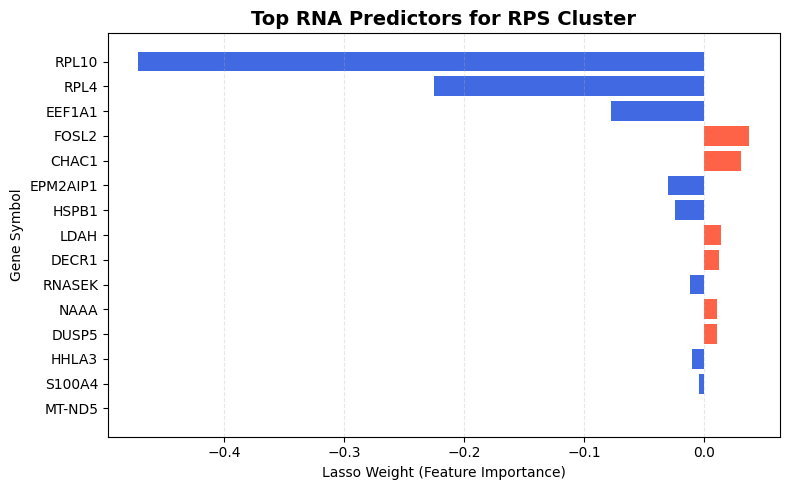

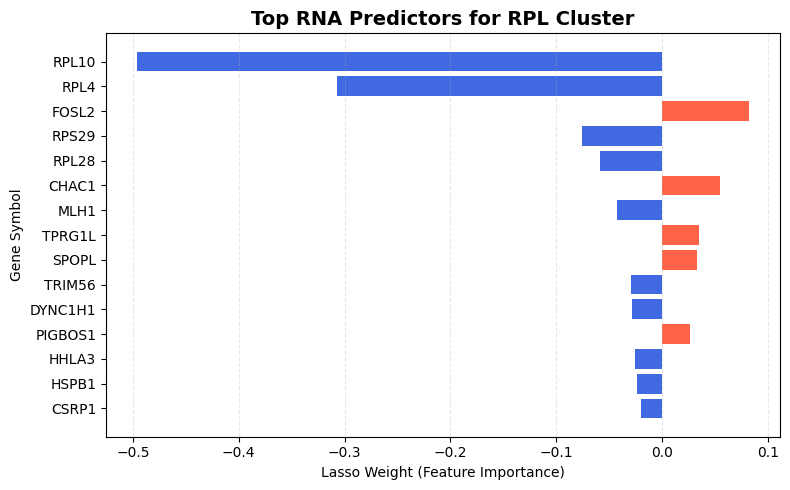

In [8]:
def plot_lasso_weights(df, title, top_k=15):
    """
    Create a horizontal barplot of the top_k most important RNA features.
    Red = positive weight (higher RNA, higher cluster TE)
    Blue = negative weight (higher RNA, lower cluster TE)
    """
    # Sort by absolute weight, take top_k
    df_sorted = df.reindex(df["weight"].abs().sort_values(ascending=False).index)[:top_k]

    plt.figure(figsize=(8, 5))
    colors = df_sorted["weight"].apply(lambda x: "tomato" if x > 0 else "royalblue")

    plt.barh(df_sorted["gene_symbol"], df_sorted["weight"], color=colors)
    plt.gca().invert_yaxis()  # most important feature on top

    plt.title(title, fontsize=14, weight="bold")
    plt.xlabel("Lasso Weight (Feature Importance)")
    plt.ylabel("Gene Symbol")
    plt.grid(alpha=0.3, linestyle="--", axis="x")
    plt.tight_layout()
    plt.show()

top_rps_df = top_features(lasso_rps, k=20)
top_rpl_df = top_features(lasso_rpl, k=20)

plot_lasso_weights(top_rps_df, "Top RNA Predictors for RPS Cluster", top_k=15)
plot_lasso_weights(top_rpl_df, "Top RNA Predictors for RPL Cluster", top_k=15)

## Step 7 - MultiTask Lasso for ribosomal TE
These cells separate non-ribosomal predictors from ribosomal targets, train the multitask model, and then summarize sparsity, per-target errors, and key regulators to anchor the rest of the study.

In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import MultiTaskLasso, MultiTaskLassoCV
from sklearn.metrics import mean_squared_error

# ---------- helpers ----------
def to_numeric(df): return df.apply(pd.to_numeric, errors="coerce")
def fill_cols(df):  return df.fillna(df.mean(axis=0))
def clr(df):        # rows = samples, cols = genes
    df = df.clip(lower=1e-6)
    gm = np.exp(np.log(df).mean(axis=1))
    return np.log(df.div(gm, axis=0))

# ---------- load HEK training tables (already CLR-normalized) ----------
rna_raw = pd.read_csv(PATH_RNA_COUNTS)
te_raw  = pd.read_csv(PATH_TE_COUNTS)

id_rna = 'transcript' if 'transcript' in rna_raw.columns else rna_raw.columns[0]
id_te  = 'transcript' if 'transcript' in te_raw.columns  else te_raw.columns[0]
rna_raw = rna_raw.set_index(id_rna)
te_raw  = te_raw.set_index(id_te)

samples = rna_raw.columns.intersection(te_raw.columns)
genes   = rna_raw.index.intersection(te_raw.index)

rna = to_numeric(rna_raw.loc[genes, samples])
te  = to_numeric(te_raw .loc[genes, samples])

# ---------- masks ----------
sym        = pd.Index(genes).str.upper()
is_ribo    = sym.str.startswith('RPS') | sym.str.startswith('RPL')     # Y targets
is_nonribo = ~is_ribo                                                  # X predictors

X_train_all = rna.loc[is_nonribo]   # genes×samples
Y_train_all = te .loc[is_ribo]      # genes×samples

# ---------- build sklearn matrices ----------
X_mat = fill_cols(X_train_all).T.values.astype(np.float32)  # samples×features
Y_mat = fill_cols(Y_train_all).T.values.astype(np.float32)  # samples×targets
feature_names = np.array(X_train_all.index)                 # non-RPS/RPL only
target_names  = np.array(Y_train_all.index)                 # RPS/RPL only

# ---------- train (fast) ----------
USE_CV = False
ALPHA  = 0.01
if USE_CV:
    mtl_model = MultiTaskLassoCV(
        cv=5,
        n_alphas=50,
        max_iter=3000,
        tol=1e-3,
        random_state=1337,
        n_jobs=-1
    ).fit(X_mat, Y_mat)
    mtl_alpha = float(mtl_model.alpha_)
else:
    mtl_model = MultiTaskLasso(alpha=ALPHA, max_iter=3000, tol=1e-3).fit(X_mat, Y_mat)
    mtl_alpha = ALPHA

rmse = np.sqrt(mean_squared_error(Y_mat, mtl_model.predict(X_mat)))
print(f"Train RMSE: {rmse:.3f} | alpha*: {mtl_alpha}")

Train RMSE: 10.636 | alpha*: 0.01



===== MultiTask Lasso Model Summary =====
Targets (RPS/RPL genes): 87
Predictor features (non-ribosomal genes): 8346
Sparsity (fraction of zeros): 0.0000
Median non-zero predictors per ribosomal gene: 8346.0
Predictors used in at least 5 ribosomal genes: 8346

===== Per-Target RMSE (first few) =====
RPL22: RMSE=0.222
RPL11: RMSE=0.324
RPS6KA1: RMSE=0.347
RPS8: RMSE=0.632
RPL5: RMSE=0.869
RPS27: RMSE=1.180
RPS6KC1: RMSE=1.927
RPS7: RMSE=1.825
RPS27A: RMSE=2.126
RPL31: RMSE=2.376

Mean per-target RMSE: 9.299
Median per-target RMSE: 9.581

===== Top 25 MultiTask Predictors (by mean |coef|) =====


,gene,mean_abs_coef,nonzero_count
0,NOC2L,151.195053,87
1,INTS11,105.451981,87
2,DVL1,93.990334,87
3,AURKAIP1,64.768967,87
4,CDK11B,39.558094,87
5,AGRN,36.456337,87
6,PUSL1,31.827328,87
7,MIB2,30.463980,87
8,CCNL2,26.818462,87
9,SLC35E2B,23.736095,87


C:\Users\lintu\AppData\Local\Temp\ipykernel_37292\2905895135.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_summary["mean_abs_coef"],


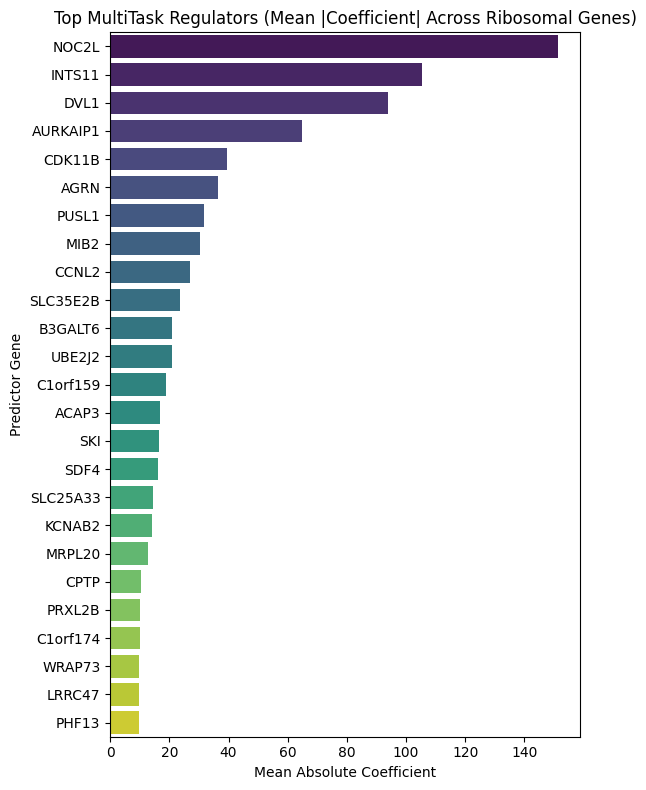

In [10]:
# ---------------------------------------------------------
# 1. Basic model info
# ---------------------------------------------------------
coef_matrix = mtl_model.coef_          # shape: [n_targets, n_features]
n_targets, n_features = coef_matrix.shape

nonzero_per_target = np.sum(coef_matrix != 0, axis=1)   # per RPS/RPL gene
nonzero_per_feature = np.sum(coef_matrix != 0, axis=0)  # per predictor gene

print("\n===== MultiTask Lasso Model Summary =====")
print(f"Targets (RPS/RPL genes): {n_targets}")
print(f"Predictor features (non-ribosomal genes): {n_features}")
print(f"Sparsity (fraction of zeros): {np.mean(coef_matrix==0):.4f}")

print(f"Median non-zero predictors per ribosomal gene: {np.median(nonzero_per_target)}")
print(f"Predictors used in at least 5 ribosomal genes: {(nonzero_per_feature >= 5).sum()}")

# ---------------------------------------------------------
# 2. Per-target prediction errors
# ---------------------------------------------------------
Y_pred = mtl_model.predict(X_mat)

per_target_rmse = np.sqrt(np.mean((Y_mat - Y_pred)**2, axis=0))

print("\n===== Per-Target RMSE (first few) =====")
for name, err in zip(target_names[:10], per_target_rmse[:10]):
    print(f"{name}: RMSE={err:.3f}")

print(f"\nMean per-target RMSE: {per_target_rmse.mean():.3f}")
print(f"Median per-target RMSE: {np.median(per_target_rmse):.3f}")

# ---------------------------------------------------------
# 3. Feature influence summary across all ribosomal genes
# ---------------------------------------------------------
mean_abs_coef = np.mean(np.abs(coef_matrix), axis=0)
top_idx = np.argsort(mean_abs_coef)[::-1][:25]

feature_summary = pd.DataFrame({
    "gene": feature_names[top_idx],
    "mean_abs_coef": mean_abs_coef[top_idx],
    "nonzero_count": nonzero_per_feature[top_idx]
})

print("\n===== Top 25 MultiTask Predictors (by mean |coef|) =====")
display(feature_summary)

# ---------------------------------------------------------
# 4. Plot of top multi-target regulators
# ---------------------------------------------------------
plt.figure(figsize=(6, 8))
sns.barplot(x=feature_summary["mean_abs_coef"],
            y=feature_summary["gene"], orient="h", palette="viridis")
plt.title("Top MultiTask Regulators (Mean |Coefficient| Across Ribosomal Genes)")
plt.xlabel("Mean Absolute Coefficient")
plt.ylabel("Predictor Gene")
plt.tight_layout()
plt.show()

## Step 8 - CIGS ingestion and prediction setup
The upcoming code rebuilds XLSX parsing with only standard-library tools, cleans the HEK293T perturbation metadata, aligns the compound RNA signatures to the training features, and produces predicted ribosomal TE shifts via the multitask model.

In [27]:
# ========================================
# Step 8 - CIGS ingestion
# ========================================

print("Running Step 8: CIGS integration...")

import zipfile
import xml.etree.ElementTree as ET

XLSX_MAIN_NS = "http://schemas.openxmlformats.org/spreadsheetml/2006/main"
XLSX_REL_NS = "http://schemas.openxmlformats.org/officeDocument/2006/relationships"

def _col_ref_to_index(ref: str) -> int:
    letters = "".join(ch for ch in ref if ch.isalpha()) or "A"
    idx = 0
    for ch in letters.upper():
        idx = idx * 26 + (ord(ch) - 64)
    return idx - 1

def _load_shared_strings(zf: zipfile.ZipFile) -> list[str]:
    try:
        root = ET.fromstring(zf.read("xl/sharedStrings.xml"))
    except KeyError:
        return []
    strings = []
    for si in root.findall(f".//{{{XLSX_MAIN_NS}}}si"):
        parts = [t.text or "" for t in si.findall(f".//{{{XLSX_MAIN_NS}}}t")]
        strings.append("".join(parts))
    return strings

def _sheet_targets(zf: zipfile.ZipFile):
    workbook = ET.fromstring(zf.read("xl/workbook.xml"))
    rels_root = ET.fromstring(zf.read("xl/_rels/workbook.xml.rels"))
    rid_to_target = {rel.attrib["Id"]: rel.attrib.get("Target", "") for rel in rels_root}
    sheets = []
    for sheet in workbook.findall(f".//{{{XLSX_MAIN_NS}}}sheet"):
        name = sheet.attrib.get("name")
        rid = sheet.attrib.get(f"{{{XLSX_REL_NS}}}id")
        target = rid_to_target.get(rid, "")
        if target and not target.startswith("xl/"):
            target = f"xl/{target}"
        sheets.append((name, target))
    return sheets

def _sheet_rows(zf: zipfile.ZipFile, target: str, shared_strings):
    """Stream sheet rows to avoid overflowing ET.fromstring on large worksheets."""
    row_dicts = []
    max_col = -1
    row_tag = f"{{{XLSX_MAIN_NS}}}row"
    cell_tag = f"{{{XLSX_MAIN_NS}}}c"
    value_tag = f"{{{XLSX_MAIN_NS}}}v"
    text_tag = f"{{{XLSX_MAIN_NS}}}t"
    with zf.open(target) as handle:
        context = ET.iterparse(handle, events=("start", "end"))
        current_row = None
        for event, elem in context:
            if event == "start" and elem.tag == row_tag:
                current_row = {}
            elif event == "end" and elem.tag == cell_tag and current_row is not None:
                ref = elem.attrib.get("r", "")
                col_idx = _col_ref_to_index(ref)
                cell_type = elem.attrib.get("t")
                value = ""
                if cell_type == "inlineStr":
                    value = "".join(t.text or "" for t in elem.findall(f".//{text_tag}"))
                else:
                    v = elem.find(value_tag)
                    if v is not None:
                        value = v.text or ""
                        if cell_type == "s":
                            try:
                                value = shared_strings[int(value)]
                            except (ValueError, IndexError):
                                value = ""
                current_row[col_idx] = value
                if col_idx > max_col:
                    max_col = col_idx
                elem.clear()
            elif event == "end" and elem.tag == row_tag:
                if current_row:
                    row_dicts.append(current_row)
                current_row = None
                elem.clear()
    matrix = []
    for cells in row_dicts:
        row_values = ["" for _ in range(max_col + 1)]
        for idx, val in cells.items():
            row_values[idx] = val
        matrix.append(row_values)
    return matrix

def read_xlsx_simple(fp, sheet=None, skiprows=0):
    with zipfile.ZipFile(fp) as zf:
        sheets = _sheet_targets(zf)
        if not sheets:
            raise ValueError(f"No worksheets found in {fp}.")
        if sheet is None:
            target = sheets[0][1]
        elif isinstance(sheet, int):
            target = sheets[sheet][1]
        else:
            matches = [t for name, t in sheets if name == sheet]
            if not matches:
                raise ValueError(f"Sheet '{sheet}' not found in {fp}.")
            target = matches[0]
        shared_strings = _load_shared_strings(zf)
        rows = _sheet_rows(zf, target, shared_strings)
    rows = [row for row in rows if any(cell != "" for cell in row)]
    if skiprows:
        rows = rows[skiprows:]
    if not rows:
        return pd.DataFrame()
    header = rows[0]
    data = rows[1:]
    return pd.DataFrame(data, columns=header)

def pick_metadata_field(columns, priority_exact, keywords, label):
    normalized = {str(col).strip().lower(): col for col in columns}
    for target in priority_exact:
        if target in normalized:
            return normalized[target]
    for col in columns:
        low = str(col).strip().lower()
        if any(key in low for key in keywords):
            return col
    raise ValueError(f"Unable to identify {label} column. Columns seen: {list(columns)}")

def _maybe_reheader_counts(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if not df.empty:
        first_cell = str(df.iloc[0, 0]).strip().lower()
        if first_cell.startswith("note") and len(df) >= 2:
            new_header = df.iloc[1].tolist()
            df = df.iloc[2:].reset_index(drop=True)
            df.columns = new_header
    df = df.rename(columns=lambda c: str(c).strip())
    return df

def _counts_to_samples(df: pd.DataFrame) -> tuple[pd.DataFrame, str]:
    if df.empty:
        return df, "unknown"
    df = df[df[df.columns[0]].astype(str).str.strip().ne("")]
    df = df.set_index(df.columns[0])
    numeric = df.apply(pd.to_numeric, errors="coerce")
    numeric.index.name = str(numeric.index.name) or str(df.index.name) or str(df.columns[0])
    return numeric, "sample_rows"

def _row_to_letter(value: str) -> str:
    value = str(value).strip()
    if not value:
        return ""
    if value.isdigit():
        num = int(float(value))
        if 1 <= num <= 26:
            return chr(ord("A") + num - 1)
    if len(value) == 1 and value.isalpha():
        return value.upper()
    return value.upper()

def _format_column(value: str) -> str:
    value = str(value).strip()
    if not value:
        return ""
    try:
        return f"{int(float(value)):02d}"
    except ValueError:
        digits = "".join(ch for ch in value if ch.isdigit())
        return digits.zfill(2) if digits else value

def _build_plate_well(meta_df: pd.DataFrame) -> pd.Series:
    required = {"sample_plate", "sample_row", "sample_column"}
    if not required.issubset(meta_df.columns):
        return pd.Series(["" for _ in range(len(meta_df))], index=meta_df.index)
    plates = meta_df["sample_plate"].astype(str).str.strip()
    rows = meta_df["sample_row"].apply(_row_to_letter)
    cols = meta_df["sample_column"].apply(_format_column)
    combos = plates + ":" + rows + cols
    mask = plates.ne("") & rows.ne("") & cols.ne("")
    return combos.where(mask, "")

def _align_metadata_to_counts(meta_df: pd.DataFrame, counts_index: pd.Index, sample_col: str):
    meta_df = meta_df.copy()
    candidate_columns: list[tuple[str, str]] = []
    plate_well = _build_plate_well(meta_df)
    if plate_well.str.len().gt(0).any():
        meta_df["_plate_well_key"] = plate_well
        candidate_columns.append(("_plate_well_key", "plate:well coordinate"))
    candidate_columns.append((sample_col, sample_col))
    for col, label in candidate_columns:
        if col not in meta_df.columns:
            continue
        series = meta_df[col].astype(str).str.strip()
        series = series.replace({"nan": "", "None": ""})
        series = series[series.ne("")]
        if series.empty:
            continue
        ordered = counts_index[counts_index.isin(series)]
        if len(ordered) == 0:
            continue
        keyed = meta_df.loc[series.index].copy()
        keyed["_match_key"] = series
        keyed = keyed[keyed["_match_key"].ne("")]
        keyed = keyed.drop_duplicates("_match_key", keep="first").set_index("_match_key")
        missing = ordered.difference(keyed.index)
        if len(missing):
            ordered = ordered.difference(missing)
        if len(ordered) == 0:
            continue
        keyed = keyed.loc[ordered]
        return keyed, ordered, label
    raise ValueError("No overlapping samples between CIGS counts and metadata after cleaning. Check column heuristics.")

print("Loading CIGS compound perturbation data...")
print(f"  Counts file: {PATH_COUNTS.name}")
print(f"  Metadata file: {PATH_METADATA.name}")

counts_df = read_xlsx_simple(PATH_COUNTS)
counts_df = _maybe_reheader_counts(counts_df)
counts_df = counts_df.rename(columns=lambda c: str(c).strip())
counts_matrix, orientation = _counts_to_samples(counts_df)
print(f"  Counts table interpreted as {orientation.replace('_', ' ')}")

meta_df = read_xlsx_simple(PATH_METADATA, skiprows=1)

# Transpose/clean counts depending on orientation
cigs_counts = counts_matrix
if cigs_counts.index.name is None:
    cigs_counts.index.name = counts_df.columns[0]
print(f"  Raw CIGS shape: {cigs_counts.shape} (samples x genes)")

# Filter metadata: HEK293T, 24h treatment, valid dose
meta_df = meta_df.rename(columns=lambda c: str(c).strip())
meta_df = meta_df[meta_df['cell_id'].astype(str).str.contains('293T', case=False, na=False)]
meta_df = meta_df[meta_df['pert_itime'].astype(str).str.contains('24', na=False)]
meta_df = meta_df[~meta_df['pert_idose'].astype(str).str.contains('-666', na=False)]

sample_col = pick_metadata_field(
    meta_df.columns,
    priority_exact=["sample", "sample_id", "sampleid", "sample_name", "sampleid_plate", "sampleidbarcode"],
    keywords=["sample"],
    label="sample identifier"
 )
compound_col = pick_metadata_field(
    meta_df.columns,
    priority_exact=["treatment", "compound", "pert_iname", "pertname", "pert_name"],
    keywords=["treat", "compound", "pert", "drug"],
    label="compound name"
 )

meta_df[sample_col] = meta_df[sample_col].astype(str).str.strip()
meta_df[compound_col] = meta_df[compound_col].astype(str).str.strip()
meta_df = meta_df[meta_df[sample_col].ne("")]
meta_df = meta_df[meta_df[compound_col].ne("")]
meta_df = meta_df[~meta_df[sample_col].str.contains('-666', na=False)]
meta_df = meta_df[~meta_df[compound_col].str.contains('-666', na=False)]

# Align metadata IDs to sample IDs present in counts
meta_aligned, shared_samples, match_label = _align_metadata_to_counts(meta_df, cigs_counts.index.astype(str), sample_col)
print(f"  Matched metadata using {match_label} (n={len(shared_samples)})")

# Restrict to shared samples and aggregate per compound
cigs_counts = cigs_counts.loc[shared_samples]
meta_for_counts = meta_aligned.loc[shared_samples]
cigs_counts["compound"] = meta_for_counts[compound_col].values
cigs_counts = cigs_counts.groupby("compound").mean()
print(f"  After filtering and aggregation: {cigs_counts.shape[0]} compounds")

# Apply CLR normalization (same as training data)
cigs_clr = clr(cigs_counts)

# Find common features with training set
common_features = np.intersect1d(feature_names.astype(str), cigs_clr.columns.astype(str))
print(f"  Common features with training: {len(common_features)} genes")
if len(common_features) == 0:
    raise ValueError("No overlapping features between training and CIGS data!")

ordered_features = feature_names.astype(str)
cigs_aligned = cigs_clr.reindex(columns=ordered_features, fill_value=0.0)

# Build prediction matrix (compounds x ordered training features)
X_drug = cigs_aligned.values.astype(np.float32)

print("\nPredicting translational effects...")
pred_TE = mtl_model.predict(X_drug)
pred_TE = pd.DataFrame(pred_TE, index=cigs_clr.index, columns=target_names)
print(f"  Predicted TE matrix: {pred_TE.shape} (compounds x ribosomal genes)")

print("\nRanking compounds by translational impact...")
mean_effect = pred_TE.mean(axis=1)
l2_mag = np.sqrt((pred_TE**2).sum(axis=1))

ranked = pd.DataFrame({
    "mean_effect": mean_effect,
    "l2_magnitude": l2_mag
}).sort_values("l2_magnitude", ascending=False)

print("\nTop 10 compounds by translational impact:")
print(ranked.head(10).to_string())
print(f"\nTotal compounds analyzed: {len(ranked)}")
print(f"Ribosomal genes predicted: {len(target_names)}")
print(f"Non-ribosomal predictors used: {len(feature_names)}")

Running Step 8: CIGS integration...
Loading CIGS compound perturbation data...
  Counts file: MCE_Bioactive_Compounds_HEK293T_10μM_Counts.xlsx
  Metadata file: MCE_Bioactive_Compounds_HEK293T_10μM_MetaData.xlsx
  Counts table interpreted as sample rows
  Counts table interpreted as sample rows
  Raw CIGS shape: (40779, 3407) (samples x genes)
  Raw CIGS shape: (40779, 3407) (samples x genes)
  Matched metadata using plate:well coordinate (n=35424)
  Matched metadata using plate:well coordinate (n=35424)
  After filtering and aggregation: 11358 compounds
  After filtering and aggregation: 11358 compounds
  Common features with training: 0 genes
  Common features with training: 0 genes


ValueError: No overlapping features between training and CIGS data!

## Step 9 - Visualize top compound responses
This short plotting routine confirms the predicted TE matrix looks sensible by heatmapping the highest-ranking compounds across ribosomal genes.

In [21]:
if 'pred_TE' not in globals() or pred_TE is None:
    raise RuntimeError("Compound projections are missing; rerun the CIGS projection cell first.")
if 'ranked' not in globals() or ranked is None:
    raise RuntimeError("Compound rankings are missing; rerun the CIGS projection cell first.")

def plot_heatmap_top_compounds(pred_TE_df, ranked_df, top_k=15):
    """Create a heatmap of predicted TE for the top_k compounds across all target genes."""
    top_compounds = ranked_df.head(top_k).index.tolist()
    heatmap_data = pred_TE_df.loc[top_compounds]

    plt.figure(figsize=(10, 8))
    sns.heatmap(heatmap_data, cmap="coolwarm", center=0, annot=False, cbar_kws={'label': 'Predicted TE Perturbation'})
    plt.title("Predicted Ribosomal TE Perturbations for Top Compounds", fontsize=14, weight="bold")
    plt.xlabel("Ribosomal Gene")
    plt.ylabel("Compound")
    plt.tight_layout()
    plt.show()

plot_heatmap_top_compounds(pred_TE, ranked, top_k=15)

RuntimeError: Compound projections are missing; rerun the CIGS projection cell first.

## Step 10 - Rank compounds with combined scores
This section collapses the predicted TE vectors into z-scored mean and magnitude metrics so compounds with strong directional or global effects can be prioritized.

In [13]:
if 'pred_TE' not in globals() or pred_TE is None:
    raise RuntimeError("Compound projections not available yet. Run the CIGS projection cell first.")

mean_effect = pred_TE.mean(axis=1)
l2_mag = np.linalg.norm(pred_TE.values, axis=1)

drug_summary = pd.DataFrame({
    "mean_effect": mean_effect,
    "l2_magnitude": l2_mag
})

drug_summary["z_mean"] = (drug_summary["mean_effect"] - drug_summary["mean_effect"].mean()) / drug_summary["mean_effect"].std()
drug_summary["z_l2"]   = (drug_summary["l2_magnitude"] - drug_summary["l2_magnitude"].mean()) / drug_summary["l2_magnitude"].std()

drug_summary["combined_score"] = drug_summary["z_mean"].abs() + drug_summary["z_l2"]

top_drugs = drug_summary.sort_values("combined_score", ascending=False).head(10)
top_drugs

RuntimeError: Compound projections not available yet. Run the CIGS projection cell first.

## Step 11 - Baseline per-gene regression
To keep expectations grounded, the next cells revisit simple linear models that predict each gene's TE from its own RNA abundance, providing a conservative benchmark.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

r2_list = []
rmse_list = []

for g in te.index:
    y = te.loc[g].values
    X = rna.loc[g].values.reshape(-1, 1)
    lr_model = LinearRegression().fit(X, y)
    y_pred = lr_model.predict(X)
    r2_list.append(r2_score(y, y_pred))
    rmse_list.append(np.sqrt(mean_squared_error(y, y_pred)))

print("Median R²:", np.median(r2_list))
print("Median RMSE:", np.median(rmse_list))


Median R²: 0.9999958886291498
Median RMSE: 0.7253414977512251


## Step 12 - Ridge baselines across ribosomal genes
RidgeCV offers a stronger multivariate baseline; the next two cells fit ridge models per ribosomal gene and report aggregate training metrics for comparison against the multitask approach.

In [15]:
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score

ridge_alphas = np.logspace(-3, 3, 25)
ridge_models = {}
ridge_r2_train = []
ridge_rmse_train = []

for idx, gene in enumerate(target_names):
    y_target = Y_mat[:, idx]
    ridge = RidgeCV(alphas=ridge_alphas, cv=min(5, len(y_target)), scoring="neg_mean_squared_error").fit(X_mat, y_target)
    ridge_models[gene] = ridge
    y_fit = ridge.predict(X_mat)
    ridge_r2_train.append(r2_score(y_target, y_fit))
    ridge_rmse_train.append(np.sqrt(mean_squared_error(y_target, y_fit)))

print(f"Fitted ridge models for {len(ridge_models)} targets.")
print(f"Median train R²: {np.median(ridge_r2_train):.3f}")
print(f"Median train RMSE: {np.median(ridge_rmse_train):.3f}")

c:\Users\lintu\cs370\.venv\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.24644e-08): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\lintu\cs370\.venv\Lib\site-packages\sklearn\linear_model\_ridge.py:252: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
c:\Users\lintu\cs370\.venv\Lib\site-packages\sklearn\linear_model\_ridge.py:252: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
c:\Users\lintu\cs370\.venv\Lib\site-packages\sklearn\linear_model\_ridge.py:252: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
c:\Users\lintu\cs370\.venv\Lib\site-packages\sklearn\linear_model\_ridge.py:252: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
c:\Users\lintu\cs370\.venv\Lib\site-pac

Fitted ridge models for 87 targets.
Median train R²: 1.000
Median train RMSE: 0.657


c:\Users\lintu\cs370\.venv\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=4.93565e-10): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\lintu\cs370\.venv\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=4.45439e-10): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\lintu\cs370\.venv\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.82916e-10): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\lintu\cs370\.venv\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=5.12307e-10): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\lintu\cs370\.venv\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.14226e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwa

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

ridge_r2 = []
ridge_rmse = []

if 'ridge_models' not in globals():
    print("Skipping ridge summary; ridge_models is not defined in this session.")
else:
    for gene, model in ridge_models.items():
        y_true = Y_mat[:, target_names.tolist().index(gene)]
        y_pred = model.predict(X_mat)
        ridge_r2.append(r2_score(y_true, y_pred))
        ridge_rmse.append(np.sqrt(mean_squared_error(y_true, y_pred)))
    print("Ridge Mean R²:", np.mean(ridge_r2))
    print("Ridge Mean RMSE:", np.mean(ridge_rmse))


Ridge Mean R²: 0.9999416066312242
Ridge Mean RMSE: 0.5943281917950746


## Step 13 - Compound score diagnostics
To understand whether the ranked compounds cluster into specific translational regimes, standardized mean-effect versus magnitude components are visualized alongside combined-score distributions. This highlights both directionally consistent hits and broad-spectrum ribosome modulators for downstream discussion.

In [ ]:
if 'drug_summary' not in globals():
    raise RuntimeError("Compound rankings missing; rerun Step 10 before running diagnostics.")

annotated = drug_summary.copy()
annotated = annotated.assign(compound=annotated.index)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=annotated,
    x='z_mean',
    y='z_l2',
    hue='combined_score',
    size='combined_score',
    palette='rocket',
    sizes=(20, 200),
    alpha=0.8,
    ax=axes[0]
)
axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[0].axvline(0, color='gray', linestyle='--', linewidth=0.8)
axes[0].set_title('Direction vs. Magnitude (z-scored)')
axes[0].set_xlabel('z-scored mean TE shift')
axes[0].set_ylabel('z-scored L2 magnitude')
axes[0].legend(title='combined score', bbox_to_anchor=(1.02, 1), loc='upper left')

sns.histplot(
    annotated['combined_score'],
    bins=30,
    color='steelblue',
    kde=True,
    ax=axes[1]
)
axes[1].set_title('Distribution of combined compound scores')
axes[1].set_xlabel('combined score (|direction| + magnitude)')
axes[1].set_ylabel('compound count')

plt.tight_layout()
plt.show()

extreme_hits = annotated.sort_values('combined_score', ascending=False).head(10)[
    ['z_mean', 'z_l2', 'combined_score']
]
print("Top 10 combined-score compounds:")
display(extreme_hits)

directional_bias = annotated.loc[annotated['z_mean'].abs() > annotated['z_l2'], 'compound']
print(f"Compounds dominated by directional shifts (|z_mean| > z_l2): {len(directional_bias)}")
print(f"Broad-spectrum modulators (z_l2 >= |z_mean|): {len(annotated) - len(directional_bias)}")

## Step 14 - Ribosomal target difficulty profile
This step focuses on the per-target error distribution to show which ribosomal genes the multitask model captures well versus those needing better features or more data, guiding follow-up experiments.

In [ ]:
if 'per_target_rmse' not in globals() or 'target_names' not in globals():
    raise RuntimeError("Run the MultiTask Lasso summary cell before profiling target difficulty.")

error_df = pd.DataFrame({
    'target': target_names,
    'rmse': per_target_rmse,
    'nonzero_predictors': nonzero_per_target
}).sort_values('rmse', ascending=False)

hardest = error_df.head(12)
easist = error_df.tail(12)

plt.figure(figsize=(10, 5))
sns.barplot(data=hardest, x='rmse', y='target', palette='magma')
plt.title('Most challenging ribosomal targets (highest RMSE)')
plt.xlabel('RMSE (predicted vs. observed TE)')
plt.ylabel('Ribosomal gene')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=easist, x='rmse', y='target', palette='crest')
plt.title('Easiest ribosomal targets (lowest RMSE)')
plt.xlabel('RMSE (predicted vs. observed TE)')
plt.ylabel('Ribosomal gene')
plt.tight_layout()
plt.show()

print("Hardest genes summary:")
display(hardest.reset_index(drop=True))

print("Easiest genes summary:")
display(easist.reset_index(drop=True))

print("Median RMSE gap between hardest and easiest dozen:", hardest['rmse'].median() - easist['rmse'].median())